In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV,
                                  RidgeClassifier, SGDClassifier,
                                  PassiveAggressiveClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectFromModel


# Berlin:
start_date_berlin = "2006-10-26"
end_date_berlin = "2021-11-04"
INPUT_FILE_NAME_BERLIN = './data-csv/case-logs/Berlin-with-topics-and-agreement-scores-all-time.csv'


# Brandenburg:
start_date_brandenburg = "2004-10-13"
end_date_brandenburg = "2019-09-25"
INPUT_FILE_NAME_BRANDENBURG = './data-csv/case-logs/Brandenburg-with-topics-and-agreement-scores-all-time-preprocessed.csv'

# Baden-Württemberg:
INPUT_FILE_NAME_BAWUE = './data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv'
start_date_bawue = "2006-06-01"
end_date_bawue = "2021-05-01"

In [2]:
df_berlin = pd.read_csv(INPUT_FILE_NAME_BERLIN)
print('Read', len(df_berlin), 'rows from', INPUT_FILE_NAME_BERLIN)
df_berlin = df_berlin.dropna(axis=1, how='all')  # drop all completely empty columns

df_brandenburg = pd.read_csv(INPUT_FILE_NAME_BRANDENBURG)
print('Read', len(df_brandenburg), 'rows from', INPUT_FILE_NAME_BRANDENBURG)
df_brandenburg = df_brandenburg.dropna(axis=1, how='all')  # drop all completely empty columns

df_bawue = pd.read_csv(INPUT_FILE_NAME_BAWUE)
print('Read', len(df_bawue), 'rows from', INPUT_FILE_NAME_BAWUE)
df_bawue = df_bawue.dropna(axis=1, how='all')  # drop all completely empty columns
df_berlin = df_berlin[df_berlin['case:is_passed_bill'] == 1]
print('Filtered to only passed bill traces, remaining rows berlin:', len(df_berlin))
df_brandenburg = df_brandenburg[df_brandenburg['case:is_passed_bill'] == 1]
print('Filtered to only passed bill traces, remaining rows brandenburg:', len(df_brandenburg))
df_bawue = df_bawue[df_bawue['case:is_passed_bill'] == 1]
print('Filtered to only passed bill traces, remaining rows bawue:', len(df_bawue))

Read 1813 rows from ./data-csv/case-logs/Berlin-with-topics-and-agreement-scores-all-time.csv
Read 1410 rows from ./data-csv/case-logs/Brandenburg-with-topics-and-agreement-scores-all-time-preprocessed.csv
Read 1465 rows from ./data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv
Filtered to only passed bill traces, remaining rows berlin: 1313
Filtered to only passed bill traces, remaining rows brandenburg: 1092
Filtered to only passed bill traces, remaining rows bawue: 833


In [3]:
# filter the data by date

print("------------------ Berlin, Brandenburg, Baden-Württemberg")
print("df rows before filtering by date:", str(len(df_berlin)) + ", " + str(len(df_brandenburg)) + ", " + str(len(df_bawue)))

# Calculate end_date by adding duration (in days) to start_time
df_berlin['end_time'] = pd.to_datetime(df_berlin['start_time']) + pd.to_timedelta(df_berlin['duration'], unit='D')
df_berlin = df_berlin[(df_berlin['start_time'] >= start_date_berlin) & (df_berlin['end_time'] <= end_date_berlin)]

df_brandenburg['end_time'] = pd.to_datetime(df_brandenburg['start_time']) + pd.to_timedelta(df_brandenburg['duration'], unit='D')
df_brandenburg = df_brandenburg[(df_brandenburg['start_time'] >= start_date_brandenburg) & (df_brandenburg['end_time'] <= end_date_brandenburg)]

df_bawue['end_time'] = pd.to_datetime(df_bawue['start_time']) + pd.to_timedelta(df_bawue['duration'], unit='D')
df_bawue = df_bawue[(df_bawue['start_time'] >= start_date_bawue) & (df_bawue['end_time'] <= end_date_bawue)]

df_berlin.drop(columns=['end_time'], inplace=True)
df_brandenburg.drop(columns=['end_time'], inplace=True)
df_bawue.drop(columns=['end_time'], inplace=True)

print("df rows after filtering by date:", str(len(df_berlin)) + ", " + str(len(df_brandenburg)) + ", " + str(len(df_bawue)))

------------------ Berlin, Brandenburg, Baden-Württemberg
df rows before filtering by date: 1313, 1092, 833
df rows after filtering by date: 501, 440, 335


In [4]:
# compute mean cycle time to compare against - cases taking longer than 10% above the mean cycle time are considered "long-running" cases

bawue_average_cycle_time = df_bawue["duration"].mean()
bawue_average_cycle_time_upper_bound = bawue_average_cycle_time + 0.1*bawue_average_cycle_time

outcome_function = lambda row: row['duration'] > bawue_average_cycle_time_upper_bound

print("average_cycle_time:", bawue_average_cycle_time_upper_bound)

average_cycle_time: 100.07701492537313


In [5]:
# split into data and target
target_berlin = df_berlin.apply(outcome_function, axis=1)
target_brandenburg = df_brandenburg.apply(outcome_function, axis=1)
target_bawue = df_bawue.apply(outcome_function, axis=1)
data_berlin = df_berlin
data_brandenburg = df_brandenburg
data_bawue = df_bawue

print("target value counts berlin:", target_berlin.value_counts())
print("target value counts brandenburg:", target_brandenburg.value_counts())
print("target value counts bawue:", target_bawue.value_counts())

target value counts berlin: False    266
True     235
Name: count, dtype: int64
target value counts brandenburg: True     272
False    168
Name: count, dtype: int64
target value counts bawue: False    252
True      83
Name: count, dtype: int64


In [6]:
for data in [data_berlin, data_brandenburg, data_bawue]:
    columns_type_object = data.select_dtypes(include=['object']).columns
    print("Dropping columns of type object:", columns_type_object)
    data.drop(columns=columns_type_object, inplace=True)
    data.fillna(0, inplace=True)

datasets_raw = {
    'Berlin':           (data_berlin, target_berlin),
    'Brandenburg':      (data_brandenburg, target_brandenburg),
    'Baden-Württemberg': (data_bawue, target_bawue),
}

Dropping columns of type object: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VorgangsDeskriptoren',
       'case:VSysL'],
      dtype='object')
Dropping columns of type object: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VSysL',
       'case:VorgangsDeskriptoren'],
      dtype='object')
Dropping columns of type object: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VSysL',
       'case:VorgangsDeskriptoren'],
      dtype='object')


## Classifiers

In [7]:
def get_classifiers():
    return {
        "Random Baseline":      "random",
        "Majority Baseline":    "majority",
        "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest":        RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42),
        "Decision Tree":        DecisionTreeClassifier(max_depth=5, random_state=42),
        "Linear SVM":           SVC(kernel="linear", C=0.025, random_state=42),
        "Ridge Classifier":     RidgeClassifier(random_state=42),
        "SGD Classifier":       SGDClassifier(random_state=42, max_iter=1000),
        "Passive Aggressive":   PassiveAggressiveClassifier(random_state=42, max_iter=1000),
        "K-Nearest Neighbors":  KNeighborsClassifier(3),
        # gamma=2 (sklearn 2-D demo value) ranks at chance on 30-100 features;
        # 'scale' is the sklearn default (1 / n_features on standardized data)
        "RBF SVM":              SVC(gamma='scale', C=1, random_state=42),
        # without restarts the kernel optimizer can run off to a huge length
        # scale and predict the base rate for every case
        "Gaussian Process":     GaussianProcessClassifier(1.0 * RBF(1.0), n_restarts_optimizer=5,
                                                          random_state=42),
        "Extra Trees":          ExtraTreesClassifier(max_depth=5, n_estimators=100, random_state=42),
        "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
         "AdaBoost":           AdaBoostClassifier(random_state=42),
        "Neural Net (MLP)":     MLPClassifier(alpha=1, max_iter=1000, random_state=42),
        "LDA":                  LinearDiscriminantAnalysis(),
    }

## Feature Groups

In [8]:
# columns to always hide
ALWAYS_HIDE = [
    'duration',
    r'.*cycle.*',
    r'.*Gesetz(?!entwurf).*', 
    r'.*Bekanntmachung.*',
    'case_id',
    r'.*none.*',
    r'(?i).*\bnan\b.*',   # only match 'nan' as a whole word
    'start_time_rel', 'start_time', 'end_time', r'.*\.start.*',
    r'.*delay.*',         # should be always hidden?
]

CONTROL_FLOW_FEATURES = [
    "event_count",
    r'.*\.count.*',
]

# --- Political features, split by data provenance ---------------------------

OUT_OF_DATA_POLITICAL_FEATURES = [
    r'.*score.*',                       # Wahl-O-Mat agreement (party alignment)
    "case:government_party_count",      # parliamentary composition
    "case:opposition_party_count",
    "case:government_seat_percentage",
    "case:opposition_seat_percentage",
    "case:is_election_year",            # electoral calendar  (JUDGMENT CALL, see notes)
    "case:half_year_index",            # temporal position from log timestamps (JUDGMENT CALL)
    "case:pdf_bytes", "case:pdf_word_count",   # business-object props (JUDGMENT CALL)
]

IN_DATA_POLITICAL_FEATURES = [
    "case:is_passed_bill",              # constant after filtering -> will be dropped
    "case:Wp",
    "case:WIP_during_start",            # active processes at start: computed from log
    "case:author_first_event_count",
    r'case:author_first_event_.*',
    r'case:vsysl.*',                    # Systematik (topic) from source data
    r'case:deskriptor_.*',             # descriptors from source data
]


POLITICAL_FEATURES = OUT_OF_DATA_POLITICAL_FEATURES + IN_DATA_POLITICAL_FEATURES

# each test case = list of hide patterns. ALWAYS_HIDE is included in all.
test_cases = {
    'Without political features': ALWAYS_HIDE + POLITICAL_FEATURES, # keep control-flow
    'Political features only':    ALWAYS_HIDE + CONTROL_FLOW_FEATURES, # keep political
    'Combined':                   ALWAYS_HIDE, # keep both

    # --- political-only isolation (hide control-flow + the other provenance) ---
    'In-data political only':
        ALWAYS_HIDE + CONTROL_FLOW_FEATURES + OUT_OF_DATA_POLITICAL_FEATURES,
    'Out-of-data political only':
        ALWAYS_HIDE + CONTROL_FLOW_FEATURES + IN_DATA_POLITICAL_FEATURES,

    # --- added on top of control-flow (the claim-relevant comparisons) ---
    'Control-flow + in-data political':
        ALWAYS_HIDE + OUT_OF_DATA_POLITICAL_FEATURES,
    'Control-flow + out-of-data political':
        ALWAYS_HIDE + IN_DATA_POLITICAL_FEATURES,
}


def apply_hide_patterns(df, patterns):
    """Drop any column matching one of the regex patterns."""
    out = df.copy()
    for pattern in patterns:
        for col in list(out.columns):
            if re.fullmatch(pattern, col):
                out = out.drop(columns=[col])
    return out

In [9]:
# 10-fold stratified CV evaluation, leakage-free.
# Same folds across all classifiers and feature sets within a region.
# Standardization (and any fitted preprocessing) happens inside each
# training fold via the pipeline. Per-fold mean ± std reported.
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     TunedThresholdClassifierCV)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

N_SPLITS = 10
SEED = 42
STD_DDOF = 1   # sample std across folds; set 0 for population std
# Tune each classifier's decision threshold for macro F1 by an inner CV on the
# training fold only (the outer test fold is never used). Only thresholded
# metrics change; ROC-AUC is threshold-free and stays identical.
TUNE_THRESHOLD = True
INNER_SPLITS = 5

scoring = {
    'roc_auc':  'roc_auc',
    'f1_macro': 'f1_macro',      # per-class F1, unweighted mean
}
METRICS = list(scoring)
PRIMARY_METRIC = 'roc_auc'     # for model selection, paper tables, and boxplots
SECONDARY_METRIC = 'f1_macro'   # threshold-based; reported next to the primary metric
METRIC_LABELS = {'roc_auc': 'ROC-AUC', 'f1_macro': 'F1 (macro)'}


class ThresholdTunedClassifier(TunedThresholdClassifierCV):
    """TunedThresholdClassifierCV that keeps the default threshold when the
    inner models predict a constant (nothing to tune) instead of failing."""
    def fit(self, X, y, **params):
        try:
            return super().fit(X, y, **params)
        except ValueError as e:
            if 'constant predictions' not in str(e):
                raise
            self.estimator_ = clone(self.estimator).fit(X, y)
            self.best_threshold_ = None
            return self

    def predict(self, X):
        if self.best_threshold_ is None:
            return self.estimator_.predict(X)
        return super().predict(X)

def as_estimator(clf):
    if clf == "random":     # class-proportional random guesser
        return DummyClassifier(strategy="stratified", random_state=SEED)
    if clf == "majority":   # always predict the majority class
        return DummyClassifier(strategy="most_frequent")
    pipe = make_pipeline(StandardScaler(), clf)   # scaler refit per training fold
    if TUNE_THRESHOLD:
        return ThresholdTunedClassifier(
            pipe, scoring='f1_macro',
            cv=StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=SEED))
    return pipe

all_scores = []

for region, (data_raw, target) in datasets_raw.items():
    for case_name, hide_patterns in test_cases.items():
        X = apply_hide_patterns(data_raw, hide_patterns).to_numpy()
        y = target.to_numpy()

        # splits depend only on (y, n, SEED) -> identical folds for every
        # classifier and every feature set within the region
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

        for method_name, clf in get_classifiers().items():
            row = {'case': case_name, 'region': region, 'method': method_name}
            try:
                cv = cross_validate(as_estimator(clf), X, y, cv=skf,
                                    scoring=scoring, n_jobs=-1,
                                    error_score='raise')
                for m in METRICS:
                    row[f'{m}_mean'] = cv[f'test_{m}'].mean()
                    row[f'{m}_std']  = cv[f'test_{m}'].std(ddof=STD_DDOF)
            except Exception as e:
                print(f"  [skip] {method_name} on {region}/{case_name}: "
                      f"{type(e).__name__}: {e}")
                for m in METRICS:
                    row[f'{m}_mean'] = row[f'{m}_std'] = np.nan
            all_scores.append(row)

scores_df = pd.DataFrame(all_scores)

# bridge: display/boxplot code reads flat metric columns. Alias the means so
# reorder_within_cases / style_region_table / boxplots work unchanged;
# the *_std columns stay in scores_df for error bars / paper tables.
for m in METRICS:
    scores_df[m] = scores_df[f'{m}_mean']

/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/gaussian_process/_gpc.py:506: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  

In [10]:
def reorder_within_cases(df):
    """Baselines first, then the rest sorted by PRIMARY_METRIC (within each case)."""
    baseline_order = ['Random Baseline', 'Majority Baseline']

    def sort_group(group):
        g = group.reset_index()
        is_baseline = g['method'].isin(baseline_order)
        baselines = g[is_baseline].copy()
        baselines['_ord'] = baselines['method'].map(
            {n: i for i, n in enumerate(baseline_order)})
        baselines = baselines.sort_values('_ord').drop(columns='_ord')
        rest = g[~is_baseline].sort_values(PRIMARY_METRIC, ascending=False)
        return pd.concat([baselines, rest], ignore_index=True)

    case_order = df.index.get_level_values('case').unique().tolist()
    parts = []
    for case in case_order:
        sub = df.xs(case, level='case', drop_level=False)
        sorted_sub = sort_group(sub).set_index(['case', 'method'])
        parts.append(sorted_sub)
    return pd.concat(parts)

def style_region_table(region_df, region_name):
    metric_cols = METRICS

    # first row of each case group, for separator borders
    cases_in_order = region_df.index.get_level_values('case')
    first_row_positions, seen = [], set()
    for pos, case in enumerate(cases_in_order):
        if case not in seen:
            first_row_positions.append(pos)
            seen.add(case)
    separator_positions = first_row_positions[1:]

    def highlight_baselines(row):
        styles = [''] * len(row)
        method = row.name[1] if isinstance(row.name, tuple) else row.name
        if 'Baseline' in method:
            styles = ['color: #888; font-weight: bold'] * len(row)
        return styles

    def highlight_best_per_case(s):
        out = pd.Series('', index=s.index)
        for case in s.index.get_level_values('case').unique():
            sub = s.xs(case, level='case')
            sub_no_baseline = sub[~sub.index.str.contains('Baseline')]
            if sub_no_baseline.notna().any():
                best_val = sub_no_baseline.max()
                for method in sub_no_baseline.index:
                    if sub_no_baseline[method] == best_val:
                        out.loc[(case, method)] = \
                            'background-color: #b8e6b8; font-weight: bold'
        return out

    styled = (
        region_df
        .style
        .apply(highlight_baselines, axis=1)
        .apply(highlight_best_per_case, subset=metric_cols)
        .background_gradient(subset=metric_cols, cmap='RdYlGn',
                             vmin=0, vmax=1, axis=None)
        .format("{:.3f}", subset=metric_cols, na_rep="—")
        .set_caption(f"<h3 style='margin:10px 0'>{region_name}</h3>")
        .set_table_styles([
            {'selector': 'td', 'props': [('padding', '6px 12px'),
                                         ('text-align', 'right')]},
            {'selector': 'th', 'props': [('padding', '6px 12px'),
                                         ('text-align', 'left'),
                                         ('background-color', '#f5f5f5')]},
            {'selector': 'th.col_heading', 'props': [('text-align', 'center')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'),
                                              ('text-align', 'left')]},
        ])
    )

    # full-width horizontal separators between case groups
    border_style = [{'selector': '', 'props': [('border-top',
                                                '2px solid #333')]}]
    for pos in separator_positions:
        styled = styled.set_table_styles(
            {region_df.index[pos]: border_style},
            overwrite=False, axis=1,
        )
    return styled


def show_region_tables(scores_df, metric=PRIMARY_METRIC, exclude_baselines=True):
    """Display one styled table per region (for notebooks),
    plus a per-case median/mean/std summary across classifiers."""
    for region in datasets_raw.keys():
        region_df = scores_df[scores_df['region'] == region].copy()
        # keep only the aliased metric columns; drop region + *_mean/*_std
        region_df = region_df.set_index(['case', 'method'])[METRICS]
        region_df = reorder_within_cases(region_df)

        # --- per-case summary across classifiers ---
        summ_df = region_df
        if exclude_baselines:
            methods = summ_df.index.get_level_values('method')
            summ_df = summ_df[~methods.str.contains('Baseline')]

        case_order = region_df.index.get_level_values('case').unique()
        summary = (summ_df.groupby(level='case')[metric]
                   .agg(['median', 'mean', 'std'])
                   .reindex(case_order)
                   .round(3))

        display(style_region_table(region_df, region))
        print(f"{region} — {METRIC_LABELS.get(metric, metric)} per-case summary "
              f"(across classifiers):")
        display(summary)

In [11]:
show_region_tables(scores_df, metric=PRIMARY_METRIC, exclude_baselines=True)

Berlin — ROC-AUC per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.662,0.656,0.029
Political features only,0.672,0.658,0.041
Combined,0.696,0.685,0.042
In-data political only,0.631,0.630,0.026
Out-of-data political only,0.607,0.602,0.030
Control-flow + in-data political,0.670,0.665,0.034
Control-flow + out-of-data political,0.668,0.655,0.042


Brandenburg — ROC-AUC per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.761,0.757,0.041
Political features only,0.634,0.652,0.048
Combined,0.759,0.756,0.050
In-data political only,0.625,0.629,0.034
Out-of-data political only,0.552,0.571,0.055
Control-flow + in-data political,0.761,0.762,0.038
Control-flow + out-of-data political,0.733,0.736,0.045


Baden-Württemberg — ROC-AUC per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.719,0.729,0.055
Political features only,0.676,0.675,0.040
Combined,0.745,0.746,0.049
In-data political only,0.675,0.663,0.035
Out-of-data political only,0.608,0.600,0.031
Control-flow + in-data political,0.761,0.766,0.044
Control-flow + out-of-data political,0.687,0.700,0.070


In [12]:
# Secondary metric: per-case summary across classifiers (baselines excluded).
# The per-classifier values are in the region tables above.
for region in datasets_raw.keys():
    sub = scores_df[(scores_df['region'] == region) &
                    (~scores_df['method'].str.contains('Baseline'))]
    summary = (sub.groupby('case', sort=False)[SECONDARY_METRIC]
               .agg(['median', 'mean', 'std'])
               .round(3))
    print(f"{region} — {METRIC_LABELS[SECONDARY_METRIC]} per-case summary "
          f"(across classifiers):")
    display(summary)

Berlin — F1 (macro) per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.599,0.590,0.047
Political features only,0.613,0.608,0.030
Combined,0.628,0.625,0.030
In-data political only,0.574,0.569,0.026
Out-of-data political only,0.562,0.559,0.032
Control-flow + in-data political,0.596,0.600,0.022
Control-flow + out-of-data political,0.590,0.596,0.032


Brandenburg — F1 (macro) per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.698,0.675,0.055
Political features only,0.579,0.601,0.046
Combined,0.680,0.680,0.034
In-data political only,0.567,0.564,0.029
Out-of-data political only,0.525,0.530,0.059
Control-flow + in-data political,0.682,0.681,0.019
Control-flow + out-of-data political,0.662,0.661,0.054


Baden-Württemberg — F1 (macro) per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.639,0.665,0.077
Political features only,0.589,0.587,0.040
Combined,0.639,0.653,0.040
In-data political only,0.579,0.575,0.024
Out-of-data political only,0.523,0.514,0.030
Control-flow + in-data political,0.674,0.673,0.043
Control-flow + out-of-data political,0.616,0.633,0.083


In [13]:
################
# boxplots 
# One subplot per parliament; within each, one box per feature set.
# Each box = scores (default: PRIMARY_METRIC) of all classifiers for that (region, case).

def plot_metric_boxplots_per_parliament(
        scores_df, figsize=(8, 4), metric=PRIMARY_METRIC,
        case_order=None, label_map=None, color_map=None, fontsize=18,
        ylim=(0.45, 0.9), chance_level=0.5, chance_label='chance level'):
    """One figure per parliament, one box per feature set; each box holds the
    15 classifiers' scores (dummy baselines excluded). Both baselines score
    AUC 0.5 in every parliament, so a dashed chance line replaces their
    markers. The same y-range in every figure keeps the parliaments
    comparable; scores outside it are reported instead of silently clipped."""
    df = scores_df[~scores_df['method'].str.contains('Baseline')]

    region_order = df['region'].drop_duplicates().tolist()
    if case_order is None:
        case_order = df['case'].drop_duplicates().tolist()

    label_map = label_map or {}
    disp_labels = [label_map.get(c, c) for c in case_order]   # short axis labels

    cmap = plt.get_cmap('Set2')
    def box_color(case, i):
        if color_map and case in color_map:
            return color_map[case]
        return cmap(i % cmap.N)

    figs, axes = [], []
    for region in region_order:
        fig, ax = plt.subplots(figsize=figsize)
        region_df = df[df['region'] == region]

        outside = region_df[(region_df[metric] < ylim[0]) | (region_df[metric] > ylim[1])]
        for _, r in outside.iterrows():
            print(f"  [outside y-range] {region} / {label_map.get(r['case'], r['case'])} / "
                  f"{r['method']}: {r[metric]:.3f}")

        positions = list(range(1, 1 + len(case_order)))
        data = [region_df.loc[region_df['case'] == c, metric].dropna().to_numpy()
                for c in case_order]

        bp = ax.boxplot(
            data, positions=positions, widths=0.6,
            patch_artist=True, showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'white',
                       'markeredgecolor': 'black', 'markersize': 5},
            medianprops={'color': 'black', 'linewidth': 1.5},
        )
        for i, (box, case) in enumerate(zip(bp['boxes'], case_order)):
            box.set_facecolor(box_color(case, i))
            box.set_alpha(0.75)

        ax.axhline(chance_level, color='#555555', linestyle='--', linewidth=1.2, zorder=1)
        ax.text(0.45, chance_level + 0.005, chance_label, ha='left', va='bottom',
                fontsize=fontsize - 4, color='#555555')

        ax.set_xticks(positions)
        ax.set_xticklabels(disp_labels, rotation=25, ha='center', fontsize=fontsize)
        ax.set_xlim(0.4, positions[-1] + 0.6)

        ax.set_xlabel('Feature set', fontsize=fontsize)
        ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=fontsize)
        ax.set_ylim(*ylim)
        ax.tick_params(axis='y', labelsize=fontsize)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

        fig.tight_layout()
        figs.append(fig)
        axes.append(ax)

    plt.show()
    return figs, axes

CASE_ORDER = [
    'Without political features',
    'Control-flow + in-data political',
    'Control-flow + out-of-data political',
    'Combined',
    'In-data political only',
    'Out-of-data political only',
    'Political features only',
]

LABEL_MAP = {
    'Without political features':           'CF',
    'Control-flow + in-data political':     'CF+In',
    'Control-flow + out-of-data political': 'CF+Out',
    'Combined':                             'CF+Pol',
    'In-data political only':               'In',
    'Out-of-data political only':           'Out',
    'Political features only':              'Pol',
}

# colour by political content so the design is legible at a glance
NONE_, IN_, OUT_, ALL_ = '#9aa0a6', '#4e79a7', '#e1812c', '#59a14f'
COLOR_MAP = {
    'Without political features':           NONE_,
    'Control-flow + in-data political':     IN_,
    'In-data political only':               IN_,
    'Control-flow + out-of-data political': OUT_,
    'Out-of-data political only':           OUT_,
    'Combined':                             ALL_,
    'Political features only':              ALL_,
}



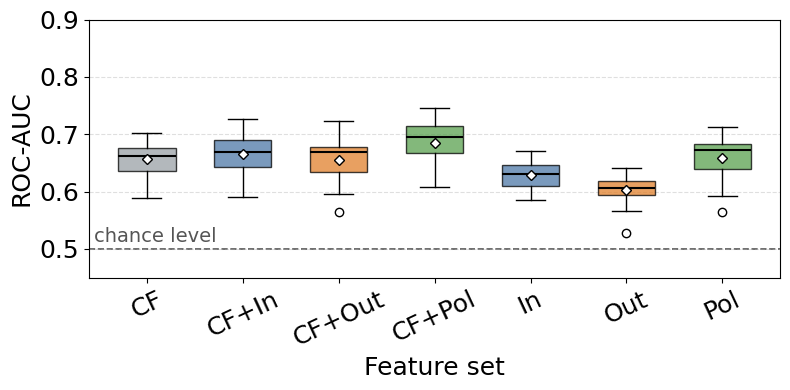

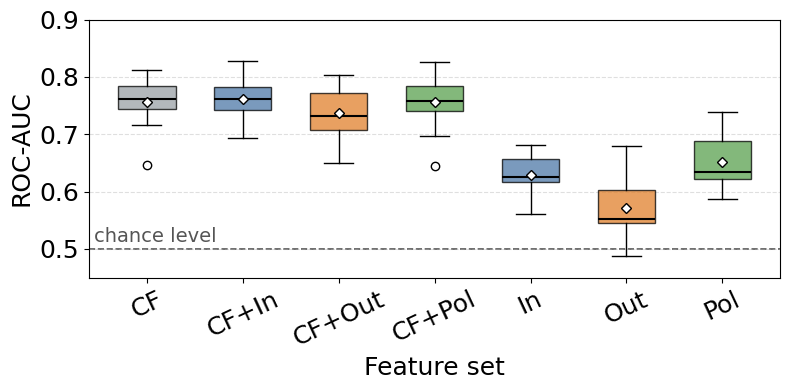

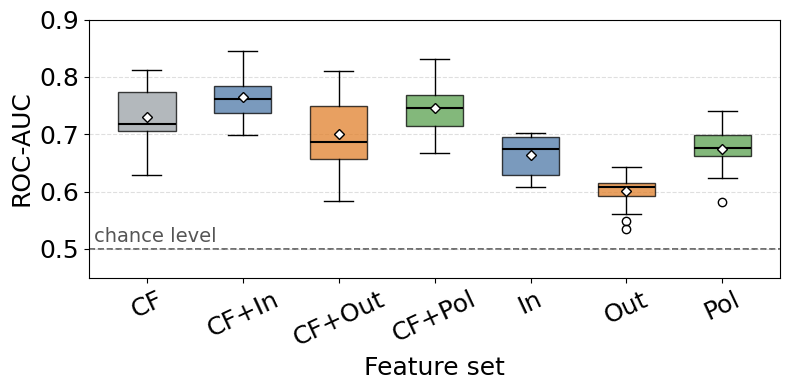

In [14]:
figs, axes = plot_metric_boxplots_per_parliament(
    scores_df, case_order=CASE_ORDER, label_map=LABEL_MAP, color_map=COLOR_MAP)

In [15]:
from scipy.stats import wilcoxon

def _pairs(scores_df, region, case_from, case_to, metric=PRIMARY_METRIC):
    sub = scores_df[(scores_df['region'] == region) &
                    (~scores_df['method'].str.contains('Baseline'))]
    wide = sub.pivot_table(index='method', columns='case', values=metric)
    for c in (case_from, case_to):
        if c not in wide:
            raise KeyError(f"{c!r} not in region {region!r}; "
                           f"available: {list(wide.columns)}")
    return wide[[case_from, case_to]].dropna()

def _holm(pvals):
    """Holm-Bonferroni adjusted p-values, returned in input order."""
    p = np.asarray(pvals, float)
    m = len(p)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        running = max(running, (m - rank) * p[idx])   # enforce monotonicity
        adj[idx] = min(running, 1.0)
    return adj

def _rank_biserial(diff):
    """Matched-pairs rank-biserial for signed-rank.
    >0 means comparison_case beats baseline_case on average."""
    d = diff[diff != 0]
    n = len(d)
    if n == 0:
        return np.nan
    ranks = pd.Series(np.abs(d)).rank().to_numpy()
    S = n * (n + 1) / 2
    return (ranks[d > 0].sum() - ranks[d < 0].sum()) / S

def paired_wilcoxon_tests(scores_df, comparisons, metric=PRIMARY_METRIC,
                          alternative='two-sided'):
    """
    comparisons: list of (region, baseline_case, comparison_case).
    Pairs the (<=15) non-baseline classifiers by name and tests whether
    comparison_case differs from baseline_case. Holm is applied across
    ALL rows (the whole family of tests).
    """
    rows = []
    for region, base, comp in comparisons:
        pair = _pairs(scores_df, region, base, comp, metric)
        b, c = pair[base].to_numpy(), pair[comp].to_numpy()
        diff = c - b
        try:
            stat, p = wilcoxon(c, b, alternative=alternative,
                               zero_method='wilcox')
        except ValueError:        # e.g. all differences zero
            p = np.nan
        rows.append({
            'region': region, 'baseline': base, 'comparison': comp,
            'n': len(diff),
            'median_baseline':   np.median(b),
            'median_comparison': np.median(c),
            'median_diff':       np.median(diff),
            'n_improved':        int((diff > 0).sum()),
            'rank_biserial':     _rank_biserial(diff),
            'p_raw':             p,
        })
    out = pd.DataFrame(rows)
    out['p_holm'] = _holm(out['p_raw'].fillna(1.0).to_numpy())
    return out

In [16]:
def summarize(scores_df, region, case_from, case_to, metric=PRIMARY_METRIC):
    pair = _pairs(scores_df, region, case_from, case_to, metric)
    diff = (pair[case_to] - pair[case_from]).to_numpy()
    n = len(diff)
    n_up   = int((diff > 0).sum())
    n_down = int((diff < 0).sum())
    n_tie  = int((diff == 0).sum())
    return {
        'region': region, 'n': n,
        'mean_diff':   float(diff.mean()),
        'median_diff': float(np.median(diff)),
        'n_up': n_up, 'pct_up': 100 * n_up / n,
        'n_down': n_down, 'pct_down': 100 * n_down / n,
        'n_tie': n_tie,
    }

def plot_slopes(scores_df, regions, case_from, case_to, metric=PRIMARY_METRIC,
                figsize=(4, 6), fontsize=13, label_map=None):
    fig, axes = plt.subplots(1, len(regions), figsize=figsize, sharey=True)
    if len(regions) == 1:
        axes = [axes]
    label_map = label_map or {}
    disp_labels = [label_map.get(c, c) for c in [case_from, case_to]]   # short axis labels

    for ax, region in zip(axes, regions):
        pair = _pairs(scores_df, region, case_from, case_to, metric)
        for _, row in pair.iterrows():
            y0, y1 = row[case_from], row[case_to]
            color = '#2a7a2a' if y1 >= y0 else '#b32020'   # green up / red down
            ax.plot([0, 1], [y0, y1], '-o', color=color, alpha=0.55,
                    markersize=4, linewidth=1.3)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(disp_labels, fontsize=fontsize - 2, ha='right')
        ax.set_xlim(-0.25, 1.25)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.tick_params(axis='y', labelsize=fontsize)
    axes[0].set_ylim(0.4, 0.9)
    axes[0].set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=fontsize)
    fig.tight_layout()
    return fig, axes

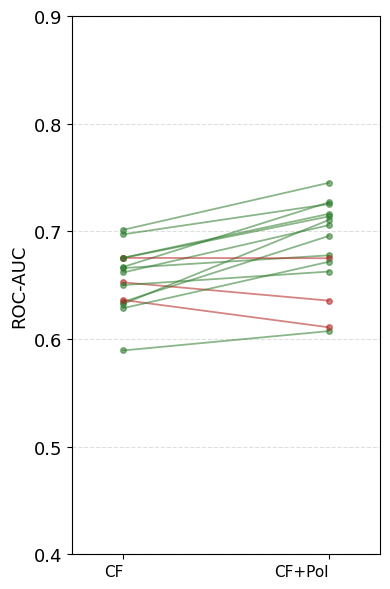

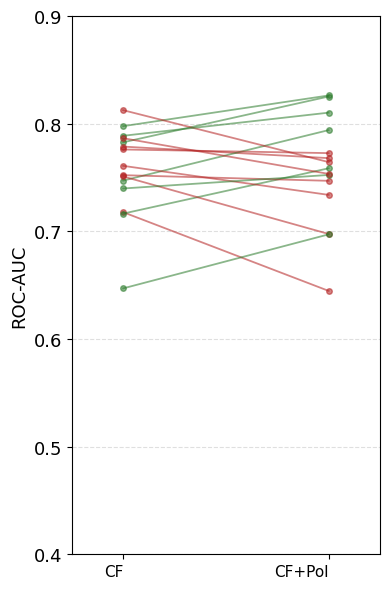

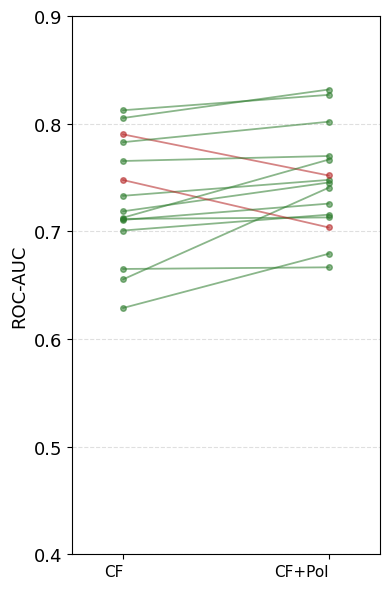

Without political features  ->  Combined  [ROC-AUC]

region                n  mean delta  median delta        improved        degraded
---------------------------------------------------------------------------------
Berlin               15      +0.029        +0.039     12/15 (80%)      3/15 (20%)
Brandenburg          15      -0.001        -0.003      7/15 (47%)      8/15 (53%)
Baden-Württemberg    15      +0.016        +0.015     13/15 (87%)      2/15 (13%)


In [17]:
CASE_FROM = 'Without political features'
CASE_TO   = 'Combined'
REGIONS   = list(datasets_raw.keys())

for region in REGIONS:
    fig, axes = plot_slopes(scores_df, [region], CASE_FROM, CASE_TO, label_map=LABEL_MAP)
    plt.show()

print(f"{CASE_FROM}  ->  {CASE_TO}  [{METRIC_LABELS[PRIMARY_METRIC]}]\n")
hdr = f"{'region':<20}{'n':>3}{'mean delta':>12}{'median delta':>14}{'improved':>16}{'degraded':>16}"
print(hdr); print('-' * len(hdr))
for region in REGIONS:
    s = summarize(scores_df, region, CASE_FROM, CASE_TO)
    up   = f"{s['n_up']}/{s['n']} ({s['pct_up']:.0f}%)"
    down = f"{s['n_down']}/{s['n']} ({s['pct_down']:.0f}%)"
    print(f"{s['region']:<20}{s['n']:>3}{s['mean_diff']:>+12.3f}"
          f"{s['median_diff']:>+14.3f}{up:>16}{down:>16}"
          + (f"   ({s['n_tie']} tied)" if s['n_tie'] else ""))

In [18]:
# Paired Wilcoxon signed-rank tests: does adding a political feature group on
# top of control flow change the score of the *same* classifier? One pair per
# classifier (n = 15), Holm-corrected across all region x comparison tests.
# The classifiers are not independent samples, so a significant result means
# "robust across model families", not "generalises to new bills".
COMPARISONS = [
    'Control-flow + in-data political',
    'Control-flow + out-of-data political',
    'Combined',
]
WILCOXON_TESTS = [(region, 'Without political features', comp)
                  for region in datasets_raw.keys() for comp in COMPARISONS]
wilcoxon_df = paired_wilcoxon_tests(scores_df, WILCOXON_TESTS)
print(f"{METRIC_LABELS[PRIMARY_METRIC]} (primary):")
display(wilcoxon_df.round(3))

# secondary metric, Holm-corrected within its own family of 9 tests
wilcoxon_secondary_df = paired_wilcoxon_tests(scores_df, WILCOXON_TESTS,
                                              metric=SECONDARY_METRIC)
print(f"{METRIC_LABELS[SECONDARY_METRIC]} (secondary):")
display(wilcoxon_secondary_df.round(3))


ROC-AUC (primary):


,region,baseline,comparison,n,median_baseline,median_comparison,median_diff,n_improved,rank_biserial,p_raw,p_holm
0,Berlin,Without political features,Control-flow + in-data political,15,0.662,0.670,0.008,10,0.517,0.083,0.333
1,Berlin,Without political features,Control-flow + out-of-data political,15,0.662,0.668,0.005,9,0.133,0.679,1.000
2,Berlin,Without political features,Combined,15,0.662,0.696,0.039,12,0.817,0.003,0.023
3,Brandenburg,Without political features,Control-flow + in-data political,15,0.761,0.761,-0.004,7,0.133,0.679,1.000
4,Brandenburg,Without political features,Control-flow + out-of-data political,15,0.761,0.733,-0.026,3,-0.683,0.018,0.108
5,Brandenburg,Without political features,Combined,15,0.761,0.759,-0.003,7,-0.017,0.978,1.000
6,Baden-Württemberg,Without political features,Control-flow + in-data political,15,0.719,0.761,0.034,13,0.933,0.000,0.004
7,Baden-Württemberg,Without political features,Control-flow + out-of-data political,15,0.719,0.687,-0.023,2,-0.833,0.003,0.021
8,Baden-Württemberg,Without political features,Combined,15,0.719,0.745,0.015,13,0.617,0.035,0.177


F1 (macro) (secondary):


,region,baseline,comparison,n,median_baseline,median_comparison,median_diff,n_improved,rank_biserial,p_raw,p_holm
0,Berlin,Without political features,Control-flow + in-data political,15,0.599,0.596,-0.000,7,0.033,0.934,1.000
1,Berlin,Without political features,Control-flow + out-of-data political,15,0.599,0.590,0.007,9,0.150,0.639,1.000
2,Berlin,Without political features,Combined,15,0.599,0.628,0.029,14,0.883,0.001,0.010
3,Brandenburg,Without political features,Control-flow + in-data political,15,0.698,0.682,-0.013,6,-0.017,0.978,1.000
4,Brandenburg,Without political features,Control-flow + out-of-data political,15,0.698,0.662,-0.002,5,-0.300,0.330,1.000
5,Brandenburg,Without political features,Combined,15,0.698,0.680,0.001,8,-0.050,0.890,1.000
6,Baden-Württemberg,Without political features,Control-flow + in-data political,15,0.639,0.674,0.003,8,0.067,0.847,1.000
7,Baden-Württemberg,Without political features,Control-flow + out-of-data political,15,0.639,0.616,-0.026,4,-0.543,0.074,0.589
8,Baden-Württemberg,Without political features,Combined,15,0.639,0.639,-0.021,7,-0.250,0.421,1.000


## Nested Feature Selection — Honest Performance Check & Frequency Table

In [ ]:
# --- Helpers ----------------------------------------------------------------

def feature_group(name):
    def matches_any(patterns):
        return any(re.fullmatch(p, name) for p in patterns)
    if matches_any(OUT_OF_DATA_POLITICAL_FEATURES):
        return 'Out-of-data political'
    if matches_any(IN_DATA_POLITICAL_FEATURES):
        return 'In-data political'
    if matches_any(CONTROL_FLOW_FEATURES):
        return 'Control-flow'
    return 'Other'


def _support_for_feature(col):
    n_missing = int(col.isna().sum())

    if not pd.api.types.is_numeric_dtype(col):
        return int(col.notna().sum()), 'other', n_missing, None

    nonnull = col.dropna().to_numpy()
    uniq = set(np.unique(nonnull)) if nonnull.size else set()

    if uniq.issubset({0, 1}):
        carriers = col.fillna(0).to_numpy() != 0
        return int(carriers.sum()), 'binary', n_missing, carriers

    if nonnull.size and np.all(np.mod(nonnull, 1) == 0) and (nonnull >= 0).all():
        carriers = col.fillna(0).to_numpy() != 0
        return int(carriers.sum()), 'count', n_missing, carriers

    return int(col.notna().sum()), 'score', n_missing, None

In [ ]:
from sklearn.metrics import get_scorer

def nested_feature_selection(
    X, y, feature_names,
    select=True,                   # False -> skip selection entirely (paired "all features" baseline)
    n_outer=N_SPLITS, n_inner=5,
    metric=PRIMARY_METRIC,
    Cs=20,
    random_state=SEED,
):
    feature_names = list(feature_names)
    d = len(feature_names)
    mode = 'l1' if select else 'none'
    print(f"Starting nested feature selection ({mode}) with {d} features.")

    outer = StratifiedKFold(n_splits=n_outer, shuffle=True,
                            random_state=random_state)

    selection_matrix = []   # rows = outer folds, cols = features (0/1)
    scorer = get_scorer(scoring[metric])
    secondary_scorer = get_scorer(scoring[SECONDARY_METRIC])
    outer_scores = []
    outer_secondary = []
    chosen_Cs = []

    for fold_i, (train, test) in enumerate(outer.split(X, y)):
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]

        # scale inside the fold; selection must not see outer-test data
        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)

        if not select:
            mask = np.ones(d, dtype=bool)
        else:
            # inner CV picks C (L1 strength). saga solver supports L1.
            # smaller C -> stronger penalty -> fewer features survive.
            l1 = LogisticRegressionCV(
                Cs=Cs,
                cv=StratifiedKFold(n_splits=n_inner, shuffle=True,
                                   random_state=random_state),
                penalty="l1",
                solver="saga",
                class_weight='balanced',   # selection not driven by the majority class
                scoring=scoring[metric],
                max_iter=20000,
                random_state=random_state,
                n_jobs=-1,
            ).fit(X_train_s, y_train)
            chosen_Cs.append(l1.C_[0])
            sel = SelectFromModel(l1, prefit=True, threshold=1e-10)
            mask = sel.get_support()

        # guard: if selection zeroed everything, keep all (rare)
        if mask.sum() == 0:
            print(f"  [{fold_i+1}/{n_outer}] WARNING: selection kept 0 "
                  f"features; keeping all {d} as fallback.")
            mask = np.ones(d, dtype=bool)

        selection_matrix.append(mask.astype(int))

        # honest score: plain LogisticRegression on the selected features of
        # the outer-train fold, evaluated on the untouched outer-test fold
        pipe = as_estimator(LogisticRegression(max_iter=1000,
                                               random_state=random_state))
        pipe.fit(X_train[:, mask], y_train)
        outer_scores.append(scorer(pipe, X_test[:, mask], y_test))
        outer_secondary.append(secondary_scorer(pipe, X_test[:, mask], y_test))

        c_info = f", C = {chosen_Cs[-1]:.4g}" if select else ""
        print(f"  [{fold_i+1}/{n_outer}] kept {mask.sum()}/{d} features{c_info}, "
              f"outer {METRIC_LABELS[metric]} = {outer_scores[-1]:.3f}, "
              f"{METRIC_LABELS[SECONDARY_METRIC]} = {outer_secondary[-1]:.3f}")

    selection_matrix = np.array(selection_matrix)
    freq = selection_matrix.mean(axis=0)   # fraction of folds keeping each

    freq_table = (pd.DataFrame({"feature": feature_names,
                                "selection_freq": freq})
                  .sort_values("selection_freq", ascending=False)
                  .reset_index(drop=True))

    # final subset = features chosen by a majority of outer folds
    final_subset = freq_table.loc[freq_table["selection_freq"] > 0.5,
                                  "feature"].tolist()

    return {
        "freq_table": freq_table,
        "final_subset": final_subset,
        "metric": metric,
        "outer_score_mean": float(np.mean(outer_scores)),
        "outer_score_std": float(np.std(outer_scores)),
        "outer_secondary_mean": float(np.mean(outer_secondary)),
        "outer_secondary_std": float(np.std(outer_secondary)),
        "selection_matrix": selection_matrix,
    }

In [ ]:
def run_nested_feature_selection_per_case(datasets_raw, test_cases,
                                          select=True, **kwargs):
    results = {}
    for region, (data_raw, target) in datasets_raw.items():
        results[region] = {}
        for case_name, hide_patterns in test_cases.items():
            print(f"\n=== Nested feature selection ({'l1' if select else 'none'}): "
                  f"{region} / {case_name} ===")

            # selection sees only this case's columns
            data_case = apply_hide_patterns(data_raw, hide_patterns)

            X = data_case.to_numpy()
            y = target.to_numpy()
            res = nested_feature_selection(
                X, y, list(data_case.columns),
                select=select, **kwargs
            )
            results[region][case_name] = res

            print(f"\n  honest outer {METRIC_LABELS[res['metric']]} = "
                  f"{res['outer_score_mean']:.3f} ± {res['outer_score_std']:.3f} "
                  f"({METRIC_LABELS[SECONDARY_METRIC]} = "
                  f"{res['outer_secondary_mean']:.3f})")
            print(f"  majority subset: {len(res['final_subset'])} features\n")
    return results

In [ ]:
fs_baseline = run_nested_feature_selection_per_case(
    datasets_raw, test_cases, select=False)

fs_l1 = run_nested_feature_selection_per_case(datasets_raw, test_cases)



=== Nested feature selection (none): Berlin / Without political features ===
Starting nested feature selection (none) with 19 features.
  [1/10] kept 19/19 features, outer ROC-AUC = 0.637, F1 (macro) = 0.586
  [2/10] kept 19/19 features, outer ROC-AUC = 0.735, F1 (macro) = 0.631
  [3/10] kept 19/19 features, outer ROC-AUC = 0.601, F1 (macro) = 0.540
  [4/10] kept 19/19 features, outer ROC-AUC = 0.675, F1 (macro) = 0.557
  [5/10] kept 19/19 features, outer ROC-AUC = 0.788, F1 (macro) = 0.760
  [6/10] kept 19/19 features, outer ROC-AUC = 0.689, F1 (macro) = 0.616
  [7/10] kept 19/19 features, outer ROC-AUC = 0.772, F1 (macro) = 0.639
  [8/10] kept 19/19 features, outer ROC-AUC = 0.691, F1 (macro) = 0.679
  [9/10] kept 19/19 features, outer ROC-AUC = 0.494, F1 (macro) = 0.519
  [10/10] kept 19/19 features, outer ROC-AUC = 0.669, F1 (macro) = 0.680

  honest outer ROC-AUC = 0.675 ± 0.081 (F1 (macro) = 0.621)
  majority subset: 19 features


=== Nested feature selection (none): Berlin / Po

/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [4/10] kept 10/11 features, C = 29.76, outer ROC-AUC = 0.558, F1 (macro) = 0.462


/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [5/10] kept 9/11 features, C = 0.6158, outer ROC-AUC = 0.587, F1 (macro) = 0.526
  [6/10] kept 9/11 features, C = 1.624, outer ROC-AUC = 0.680, F1 (macro) = 0.694


...

  [8/10] kept 10/11 features, C = 78.48, outer ROC-AUC = 0.550, F1 (macro) = 0.455


/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [9/10] kept 10/11 features, C = 4.281, outer ROC-AUC = 0.515, F1 (macro) = 0.361


/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  [10/10] kept 8/11 features, C = 0.6158, outer ROC-AUC = 0.725, F1 (macro) = 0.612

  honest outer ROC-AUC = 0.618 ± 0.066 (F1 (macro) = 0.538)
  majority subset: 10 features


=== Nested feature selection (l1): Baden-Württemberg / Control-flow + in-data political ===
Starting nested feature selection (l1) with 64 features.
  [1/10] kept 43/64 features, C = 1.624, outer ROC-AUC = 0.671, F1 (macro) = 0.598
  [2/10] kept 57/64 features, C = 206.9, outer ROC-AUC = 0.809, F1 (macro) = 0.744
  [3/10] kept 57/64 features, C = 206.9, outer ROC-AUC = 1.000, F1 (macro) = 0.961
  [4/10] kept 48/64 features, C = 4.281, outer ROC-AUC = 0.798, F1 (macro) = 0.701
  [5/10] kept 55/64 features, C = 78.48, outer ROC-AUC = 0.841, F1 (macro) = 0.701
  [6/10] kept 54/64 features, C = 78.48, outer ROC-AUC = 0.865, F1 (macro) = 0.752
  [7/10] kept 58/64 features, C = 545.6, outer ROC-AUC = 0.785, F1 (macro) = 0.698
  [8/10] kept 52/64 features, C = 29.76, outer ROC-AUC = 0.635, F1 (macro) = 0.446
  [9/10] 

In [ ]:
def report_nested_selection_performance(fs_baseline, fs_selected, selector_name,
                                        key='score'):
    label = METRIC_LABELS[PRIMARY_METRIC if key == 'score' else SECONDARY_METRIC]
    print("\n" + "=" * 90)
    print(f"DOES {selector_name} SELECTION HURT PERFORMANCE? (nested CV, honest {label})")
    print("=" * 90)
    for region, cases in fs_selected.items():
        print(f"\n  {region}")
        print(f"  {'case':<38}{'kept':>6}{'selected':>16}{'all features':>18}{'delta':>9}")
        print(f"  {'-' * 87}")
        for case_name, res in cases.items():
            base = fs_baseline[region][case_name]
            n_kept = len(res['final_subset'])
            sel = f"{res[f'outer_{key}_mean']:.3f} ± {res[f'outer_{key}_std']:.3f}"
            all_ = f"{base[f'outer_{key}_mean']:.3f} ± {base[f'outer_{key}_std']:.3f}"
            delta = res[f'outer_{key}_mean'] - base[f'outer_{key}_mean']
            print(f"  {case_name:<38}{n_kept:>6}{sel:>16}{all_:>18}{delta:>+9.3f}")

report_nested_selection_performance(fs_baseline, fs_l1, "L1-LogReg")
report_nested_selection_performance(fs_baseline, fs_l1, "L1-LogReg", key='secondary')


DOES L1-LogReg SELECTION HURT PERFORMANCE? (nested CV, honest ROC-AUC)

  Berlin
  case                                    kept        selected      all features    delta
  ---------------------------------------------------------------------------------------
  Without political features                10   0.675 ± 0.081     0.675 ± 0.081   +0.000
  Political features only                   35   0.693 ± 0.049     0.674 ± 0.049   +0.018
  Combined                                  61   0.714 ± 0.067     0.714 ± 0.066   +0.000
  In-data political only                    27   0.643 ± 0.070     0.638 ± 0.078   +0.006
  Out-of-data political only                 4   0.591 ± 0.038     0.604 ± 0.059   -0.013
  Control-flow + in-data political          56   0.692 ± 0.083     0.691 ± 0.084   +0.001
  Control-flow + out-of-data political      20   0.693 ± 0.053     0.693 ± 0.053   +0.000

  Brandenburg
  case                                    kept        selected      all features    delta
  -

In [ ]:
def build_frequency_table(fs_selected, datasets_raw,
                          case_name='Political features only', min_freq=0.6):
    marker = {'Out-of-data political': '•', 'In-data political': '◦'}
    rows = []
    for region, cases in fs_selected.items():
        data_raw, target = datasets_raw[region]
        y = target.to_numpy().astype(bool)
        n_cases = len(data_raw)
        base_rate_pct = 100 * y.mean()

        freq_table = cases[case_name]['freq_table']
        stable = freq_table[freq_table['selection_freq'] >= min_freq]

        for _, r in stable.iterrows():
            feat = r['feature']
            if feat not in data_raw.columns:
                continue
            col = data_raw[feat]
            support, kind, n_missing, carriers = _support_for_feature(col)
            delayed_pct = (100 * y[carriers].mean()
                          if kind == 'binary' and support > 0 else np.nan)
            rows.append({
                'region': region,
                'P': marker.get(feature_group(feat), '?'),
                'feature': feat,
                'frequency': round(r['selection_freq'], 2),
                'support': support,
                'support_pct': round(100 * support / n_cases, 1),
                'delayed_pct': (round(delayed_pct, 1)
                               if not np.isnan(delayed_pct) else np.nan),
                'lift':        (round(delayed_pct / base_rate_pct, 2)
                               if not np.isnan(delayed_pct) else np.nan),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(['region', 'lift'],
                          ascending=[True, False], na_position='last')


freq_table_l1 = build_frequency_table(fs_l1, datasets_raw)

for region in datasets_raw.keys():
    base_rate_pct = 100 * datasets_raw[region][1].mean()
    print(f"--- {region}: political features with leakage-free selection "
         f"frequency >= 0.6 (nested CV, 'Political features only' case); "
         f"base rate {base_rate_pct:.1f}% long-running ---")
    display(freq_table_l1[freq_table_l1['region'] == region]
           .drop(columns='region'))

--- Berlin: political features with leakage-free selection frequency >= 0.6 (nested CV, 'Political features only' case); base rate 46.9% long-running ---


,P,feature,frequency,support,support_pct,delayed_pct,lift
27,◦,case:author_first_event_sonstige,0.8,2,0.4,100.0,2.13
5,◦,case:deskriptor_Finanzpolitik,1.0,9,1.8,88.9,1.90
11,◦,case:vsysl_Innere Sicherheit,1.0,19,3.8,84.2,1.80
2,◦,case:deskriptor_Öffentliche Sicherheit und Ord...,1.0,12,2.4,83.3,1.78
4,◦,case:deskriptor_Länder der Bundesrepublik Deut...,1.0,11,2.2,81.8,1.74
8,◦,case:deskriptor_Anstalt des öffentlichen Rechts,1.0,10,2.0,80.0,1.71
19,◦,case:deskriptor_Zuständigkeit (Verwaltung),0.9,31,6.2,71.0,1.51
13,◦,case:vsysl_Wahlen,1.0,10,2.0,70.0,1.49
3,◦,case:deskriptor_Staatsvertrag,1.0,50,10.0,66.0,1.41
34,◦,case:vsysl_Öffentliche Verwaltung,0.6,36,7.2,58.3,1.24


--- Brandenburg: political features with leakage-free selection frequency >= 0.6 (nested CV, 'Political features only' case); base rate 61.8% long-running ---


,P,feature,frequency,support,support_pct,delayed_pct,lift
35,◦,case:deskriptor_Kindertagesstättengesetz,1.0,9,2.0,100.0,1.62
41,◦,case:deskriptor_Berlin,1.0,16,3.6,93.8,1.52
42,◦,case:deskriptor_Datenschutz,1.0,33,7.5,87.9,1.42
38,◦,case:deskriptor_Staatsvertrag,1.0,69,15.7,87.0,1.41
36,◦,case:deskriptor_Grundrechtsbeschränkung,1.0,42,9.5,78.6,1.27
44,◦,case:vsysl_Wahlen,0.8,12,2.7,75.0,1.21
45,◦,case:vsysl_Kommunale Angelegenheiten,0.8,31,7.0,71.0,1.15
43,◦,case:deskriptor_sonstige,0.9,438,99.5,62.1,1.00
37,◦,case:author_first_event_christlich demokratisc...,1.0,25,5.7,32.0,0.52
39,◦,case:author_first_event_sonstige,1.0,25,5.7,20.0,0.32


--- Baden-Württemberg: political features with leakage-free selection frequency >= 0.6 (nested CV, 'Political features only' case); base rate 24.8% long-running ---


,P,feature,frequency,support,support_pct,delayed_pct,lift
54,◦,"case:vsysl_Rundfunk, Fernsehen",1.0,13,3.9,84.6,3.42
53,◦,case:vsysl_Staatsaufbau,1.0,5,1.5,60.0,2.42
50,◦,case:deskriptor_Staatsvertrag,1.0,17,5.1,52.9,2.14
57,◦,case:deskriptor_Besoldung,1.0,13,3.9,46.2,1.86
70,◦,case:vsysl_Öffentlicher Dienst,0.9,27,8.1,33.3,1.35
60,◦,case:vsysl_Öffentliche Verwaltung,1.0,13,3.9,30.8,1.24
77,◦,case:vsysl_Hochschulwesen,0.7,17,5.1,29.4,1.19
59,◦,case:author_first_event_landesregierung,1.0,290,86.6,26.9,1.09
61,◦,case:deskriptor_sonstige,1.0,301,89.9,26.2,1.06
52,◦,case:vsysl_Wahlen,1.0,12,3.6,25.0,1.01
